# Unclipped unified surface forcing and n=3 shear for ALHIC1901

This notebook repeats the corresponding unified fit without the prescribed basal packet. The earlier notebook reflected and translated a near-surface map into the bottom of the 160 m column, then set the material coordinate to zero above a fitted packet top. That operation imposed a sharp young-ice boundary at about 141 m in the selected fit.

Here the surface-forced material coordinate is calculated continuously over the actual 160 m thickness. The same field is then sheared by the gravity-driven slab solution. There is no packet top, reflection, translation, vertical clipping, or replacement age within the ice. Material traced backward through the physical accumulation boundary may still have a nonpositive source depth; assigning that material the fitted young limiting age is the stated surface boundary condition rather than an interior contact.

## Data and fold targets

The observations and scoring rule are unchanged. All 88 ALHIC1901 $^{40}$Ar$_{ATM}$ ages are fitted with their relative errors and a 0.15 Ma model-discrepancy floor. Three independently defined peaks in 0.6 m-bin medians between 141 and 155 m supply the fold target.

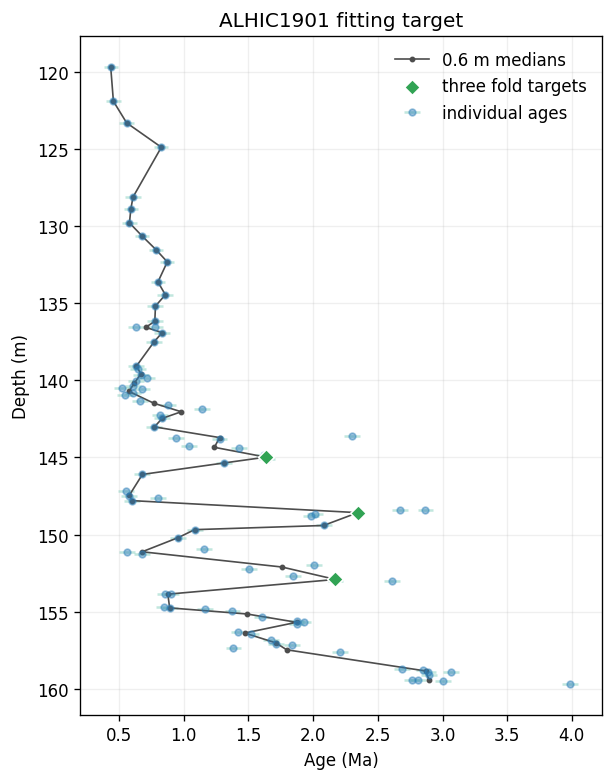

In [1]:
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="Unable to import recommended hash.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from IPython.display import Markdown, display
from scipy.optimize import differential_evolution
from scipy.signal import find_peaks
import firedrake as fd

logging.getLogger("tsfc").setLevel(logging.ERROR)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})

data_path = Path("data/shackleton.pnas.2502681122.sd01.xlsx")
if not data_path.exists():
    data_path = Path("../data/shackleton.pnas.2502681122.sd01.xlsx")
workbook = openpyxl.load_workbook(data_path, read_only=True, data_only=True)
sheet = workbook["Ar and Water isotopes"]
rows = [
    (float(row[1]), float(row[8]), float(row[9]), float(row[10]))
    for row in sheet.iter_rows(min_row=3, values_only=True)
    if row[0] == "ALHIC1901" and isinstance(row[8], (int, float))
]
observations = np.asarray(sorted(rows), dtype=float)
depth, age, relative_error, absolute_error = observations.T

BIN_WIDTH = 0.6
bin_edges = np.arange(119.5, 160.1 + BIN_WIDTH, BIN_WIDTH)
bin_depth, bin_age = [], []
for left, right in zip(bin_edges[:-1], bin_edges[1:]):
    selected = (depth >= left) & (depth < right)
    if np.any(selected):
        bin_depth.append(np.mean(depth[selected]))
        bin_age.append(np.median(age[selected]))
bin_depth, bin_age = np.asarray(bin_depth), np.asarray(bin_age)
fold_bins = (bin_depth >= 141.0) & (bin_depth <= 155.0)
peak_indices = find_peaks(bin_age[fold_bins], prominence=0.3, distance=3)[0]
observed_peak_depths = bin_depth[fold_bins][peak_indices]
observed_peak_ages = bin_age[fold_bins][peak_indices]
assert len(observed_peak_depths) == 3

fig, ax = plt.subplots(figsize=(5.0, 6.4), constrained_layout=True)
ax.errorbar(age, depth, xerr=relative_error, fmt="o", ms=4, alpha=0.48,
            color="#2c7fb8", ecolor="#7fcdbb", label="individual ages")
ax.plot(bin_age, bin_depth, ".-", color="0.3", lw=1, ms=5, label="0.6 m medians")
ax.scatter(observed_peak_ages, observed_peak_depths, marker="D", s=45,
           color="#31a354", edgecolor="white", zorder=5, label="three fold targets")
ax.invert_yaxis()
ax.set(xlabel="Age (Ma)", ylabel="Depth (m)", title="ALHIC1901 fitting target")
ax.legend(frameon=False)
plt.show()

## Full-Stokes fields over the actual ice thickness

The gravity-driven slab and periodic surface cells use n=3 rheology, the complete symmetric velocity gradient, incompressibility, and the same boundary conditions as the earlier notebook. The surface cells now have physical aspect ratio $H/\lambda$, with $H=160$ m and $\lambda=27.42$ or 60 m. Their lower no-slip boundary is therefore the actual bed, not an arbitrary continuation below the modeled column.

This remains a sequential kinematic experiment: a finite surface-forcing episode creates a continuous material map, and the steady slab subsequently shears it. The calculation does not prescribe transport from the surface to the bed.

In [2]:
L, H = 2_000.0, 160.0
RHO, G, ALPHA = 917.0, 9.81, 0.03
GLEN_N = 3.0
REFERENCE_MU = 2.5e8
EPS_REG = 1e-10
UNIT_EPS_REG = 1e-3
DRIVING = RHO * G * np.sin(ALPHA)
SURFACE_SPEED = DRIVING * H**2 / (2 * REFERENCE_MU)
SOFTNESS = SURFACE_SPEED * (GLEN_N + 1) / (
    2 * DRIVING**GLEN_N * H**(GLEN_N + 1)
)

def analytical_velocity(height):
    return 2 * SOFTNESS * DRIVING**GLEN_N / (GLEN_N + 1) * (
        H**(GLEN_N + 1) - (H - height)**(GLEN_N + 1)
    )

def solve_slab(nx, nz):
    mesh = fd.RectangleMesh(nx, nz, L, H)
    V = fd.VectorFunctionSpace(mesh, "CG", 2)
    Q = fd.FunctionSpace(mesh, "CG", 1)
    mixed = V * Q
    z = fd.SpatialCoordinate(mesh)[1]
    solution = fd.Function(mixed, name=f"slab_n{GLEN_N:g}_{nx}_{nz}")
    u, p = fd.split(solution)
    v, q = fd.TestFunctions(mixed)
    strain = fd.sym(fd.grad(u))
    effective_strain = fd.sqrt(0.5 * fd.inner(strain, strain) + EPS_REG**2)
    viscosity = 0.5 * SOFTNESS**(-1 / GLEN_N) * effective_strain**(
        (1 - GLEN_N) / GLEN_N
    )
    body = fd.Constant((RHO * G * np.sin(ALPHA), -RHO * G * np.cos(ALPHA)))
    residual = (
        2 * viscosity * fd.inner(strain, fd.sym(fd.grad(v)))
        - p * fd.div(v) - q * fd.div(u) - fd.dot(body, v)
    ) * fd.dx
    side_velocity = fd.as_vector((analytical_velocity(z), 0.0))
    bcs = [
        fd.DirichletBC(mixed.sub(0), side_velocity, 1),
        fd.DirichletBC(mixed.sub(0), side_velocity, 2),
        fd.DirichletBC(mixed.sub(0), fd.Constant((0.0, 0.0)), 3),
    ]
    solution.sub(0).interpolate(side_velocity)
    solution.sub(1).interpolate(RHO * G * np.cos(ALPHA) * (H - z))
    fd.solve(residual == 0, solution, bcs=bcs, solver_parameters={
        "snes_type": "newtonls", "snes_linesearch_type": "bt", "snes_rtol": 1e-9,
        "ksp_type": "preonly", "pc_type": "lu", "pc_factor_mat_solver_type": "mumps",
    })
    velocity, pressure = solution.subfunctions
    heights = np.linspace(0.0, H, 1601)
    points = np.column_stack((np.full_like(heights, L / 2), heights))
    profile = np.asarray(velocity.at(points, tolerance=1e-10))[:, 0]
    divergence = fd.project(fd.div(velocity), Q)
    div_l2 = np.sqrt(float(fd.assemble(divergence**2 * fd.dx)))
    grad_l2 = np.sqrt(float(fd.assemble(
        fd.inner(fd.grad(velocity), fd.grad(velocity)) * fd.dx
    )))
    return {
        "velocity": velocity, "profile": profile, "heights": heights,
        "divergence_ratio": div_l2 / grad_l2, "nx": nx, "nz": nz,
    }

def solve_surface_cell(wavelength, nx, ny):
    aspect = H / wavelength
    mesh = fd.PeriodicRectangleMesh(nx, ny, 1.0, aspect, direction="x")
    V = fd.VectorFunctionSpace(mesh, "CG", 2)
    Q = fd.FunctionSpace(mesh, "CG", 1)
    mixed = V * Q
    x, z = fd.SpatialCoordinate(mesh)
    y = aspect - z
    solution = fd.Function(
        mixed, name=f"surface_n{GLEN_N:g}_{wavelength:g}_{nx}_{ny}"
    )
    u, p = fd.split(solution)
    v, q = fd.TestFunctions(mixed)
    top_velocity = fd.as_vector((0.0, -fd.sin(2 * np.pi * x)))
    bcs = [
        fd.DirichletBC(mixed.sub(0), fd.Constant((0.0, 0.0)), 1),
        fd.DirichletBC(mixed.sub(0), top_velocity, 2),
    ]
    k = 2 * np.pi
    solution.sub(0).interpolate(fd.as_vector((
        -k * y * fd.exp(-k * y) * fd.cos(k * x),
        -(1 + k * y) * fd.exp(-k * y) * fd.sin(k * x),
    )))
    solution.sub(1).assign(0.0)
    nullspace = fd.MixedVectorSpaceBasis(
        mixed, [mixed.sub(0), fd.VectorSpaceBasis(constant=True)]
    )
    for exponent in (1.0, 1.5, 2.0, 2.5, 3.0):
        strain = fd.sym(fd.grad(u))
        effective_strain = fd.sqrt(0.5 * fd.inner(strain, strain) + UNIT_EPS_REG**2)
        viscosity = 0.5 * effective_strain**((1 - exponent) / exponent)
        residual = (
            2 * viscosity * fd.inner(strain, fd.sym(fd.grad(v)))
            - p * fd.div(v) - q * fd.div(u)
        ) * fd.dx
        fd.solve(
            residual == 0, solution, bcs=bcs, nullspace=nullspace,
            transpose_nullspace=nullspace,
            solver_parameters={
                "snes_type": "newtonls", "snes_linesearch_type": "bt", "snes_rtol": 1e-8,
                "ksp_type": "preonly", "pc_type": "lu",
                "pc_factor_mat_solver_type": "mumps",
                "mat_mumps_icntl_24": 1, "mat_mumps_icntl_13": 1,
            },
        )
    velocity, pressure = solution.subfunctions
    divergence = fd.project(fd.div(velocity), Q)
    div_l2 = np.sqrt(float(fd.assemble(divergence**2 * fd.dx)))
    grad_l2 = np.sqrt(float(fd.assemble(
        fd.inner(fd.grad(velocity), fd.grad(velocity)) * fd.dx
    )))
    return {
        "velocity": velocity, "pressure": pressure, "aspect": aspect,
        "divergence_ratio": div_l2 / grad_l2, "nx": nx, "ny": ny,
        "wavelength": wavelength,
    }

coarse_slab = solve_slab(80, 16)
fine_slab = solve_slab(160, 32)

surface_wavelengths = (27.42, 60.0)
surface_depth_grid = np.linspace(0.0, H, 641)
surface_phase_grid = np.linspace(0.0, 1.0, 129, endpoint=False)

def surface_velocity_grid(result):
    wavelength = result["wavelength"]
    X, Y = np.meshgrid(surface_phase_grid, surface_depth_grid)
    points = np.column_stack((X.ravel(), (result["aspect"] - Y / wavelength).ravel()))
    values = np.asarray(result["velocity"].at(points, tolerance=1e-9)).reshape(
        len(surface_depth_grid), len(surface_phase_grid), 2
    )
    values[:, :, 1] *= -1.0
    return values

surface_fields = {}
for wavelength in surface_wavelengths:
    aspect = H / wavelength
    coarse_ny = int(np.ceil(16 * aspect / 8) * 8)
    fine_ny = 2 * coarse_ny
    coarse_solution = solve_surface_cell(wavelength, 16, coarse_ny)
    fine_solution = solve_surface_cell(wavelength, 32, fine_ny)
    coarse_grid = surface_velocity_grid(coarse_solution)
    fine_grid = surface_velocity_grid(fine_solution)
    surface_fields[wavelength] = {
        "coarse": coarse_solution, "fine": fine_solution,
        "coarse_grid": coarse_grid, "fine_grid": fine_grid,
        "mesh_difference": np.max(np.abs(fine_grid - coarse_grid)),
    }

def unit_velocity(phase, depth, field):
    phase, depth = np.broadcast_arrays(
        np.asarray(phase, dtype=float), np.asarray(depth, dtype=float)
    )
    phase_periodic = np.mod(phase, 1.0)
    i_float = phase_periodic * len(surface_phase_grid)
    i0 = np.floor(i_float).astype(int) % len(surface_phase_grid)
    i1 = (i0 + 1) % len(surface_phase_grid)
    fx = i_float - np.floor(i_float)
    depth_clipped = np.clip(depth, 0.0, H)
    j_float = depth_clipped / (surface_depth_grid[1] - surface_depth_grid[0])
    j0 = np.minimum(np.floor(j_float).astype(int), len(surface_depth_grid) - 2)
    j1 = j0 + 1
    fy = np.minimum(j_float - j0, 1.0)
    values = (
        (1 - fx)[..., None] * (1 - fy)[..., None] * field[j0, i0]
        + fx[..., None] * (1 - fy)[..., None] * field[j0, i1]
        + (1 - fx)[..., None] * fy[..., None] * field[j1, i0]
        + fx[..., None] * fy[..., None] * field[j1, i1]
    )
    outside = (depth < 0.0) | (depth > H)
    return np.where(outside[..., None], 0.0, values)

firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


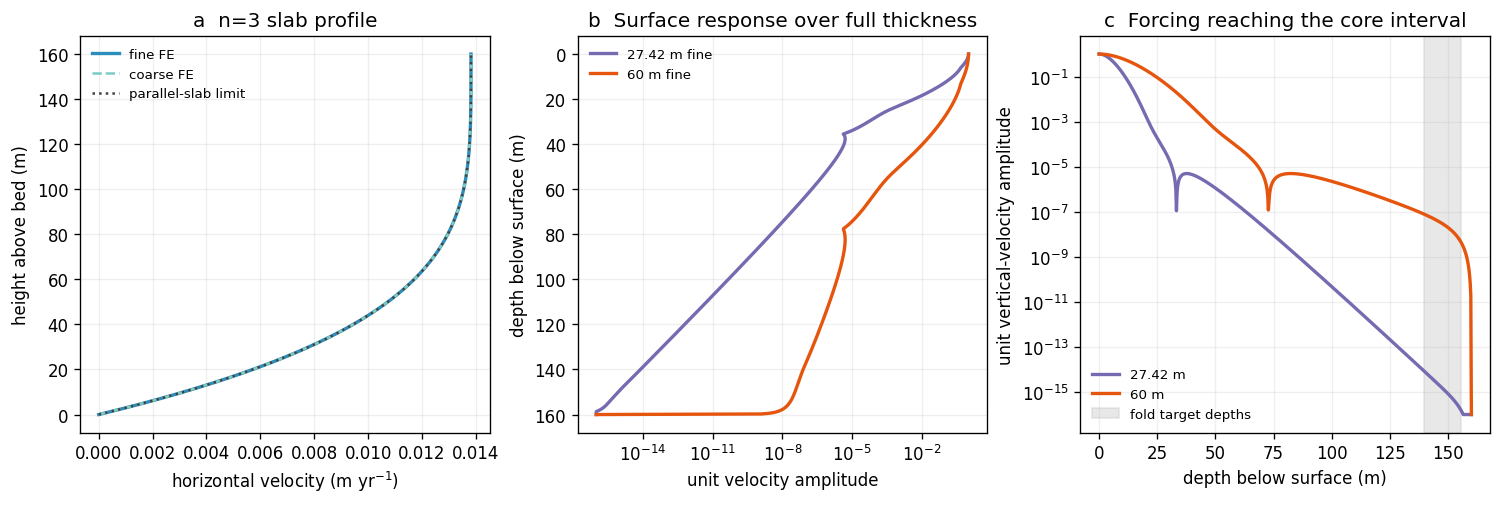

The fine slab differs from the analytical n=3 profile by **0.001%** of the surface speed. Surface-grid factor-two differences are **3.85e-03** and **3.34e-03** in unit velocity for the 27.42 and 60 m cells, respectively.

In [3]:
profile_heights = fine_slab["heights"]
analytic_profile = analytical_velocity(profile_heights)

fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.1), constrained_layout=True)
axes[0].plot(fine_slab["profile"], profile_heights, color="#2b8cbe", lw=2, label="fine FE")
axes[0].plot(coarse_slab["profile"], profile_heights, "--", color="#7bccc4", label="coarse FE")
axes[0].plot(analytic_profile, profile_heights, ":", color="0.25", label="parallel-slab limit")
axes[0].set(xlabel="horizontal velocity (m yr$^{-1}$)", ylabel="height above bed (m)",
            title=f"a  n={GLEN_N:g} slab profile")
axes[0].legend(frameon=False, fontsize=8)

for wavelength, color in zip(surface_wavelengths, ["#756bb1", "#e6550d"]):
    fine_grid = surface_fields[wavelength]["fine_grid"]
    coarse_grid = surface_fields[wavelength]["coarse_grid"]
    fine_amplitude = np.max(np.linalg.norm(fine_grid, axis=2), axis=1)
    coarse_amplitude = np.max(np.linalg.norm(coarse_grid, axis=2), axis=1)
    axes[1].semilogx(np.maximum(fine_amplitude, 1e-16), surface_depth_grid,
                     color=color, lw=2, label=f"{wavelength:g} m fine")
    axes[1].semilogx(np.maximum(coarse_amplitude, 1e-16), surface_depth_grid,
                     "--", color=color, lw=1)
axes[1].invert_yaxis()
axes[1].set(xlabel="unit velocity amplitude", ylabel="depth below surface (m)",
            title="b  Surface response over full thickness")
axes[1].legend(frameon=False, fontsize=8)

for wavelength, color in zip(surface_wavelengths, ["#756bb1", "#e6550d"]):
    field = surface_fields[wavelength]["fine_grid"]
    vertical_amplitude = np.max(np.abs(field[:, :, 1]), axis=1)
    axes[2].semilogy(surface_depth_grid, np.maximum(vertical_amplitude, 1e-16),
                     color=color, lw=2, label=f"{wavelength:g} m")
axes[2].axvspan(139.5, 155.5, color="0.75", alpha=0.35, label="fold target depths")
axes[2].set(xlabel="depth below surface (m)", ylabel="unit vertical-velocity amplitude",
            title="c  Forcing reaching the core interval")
axes[2].legend(frameon=False, fontsize=8)
plt.show()

slab_error = np.max(np.abs(fine_slab["profile"] - analytic_profile)) / SURFACE_SPEED
display(Markdown(
    f"The fine slab differs from the analytical n={GLEN_N:g} profile by "
    f"**{100 * slab_error:.3f}%** of the surface speed. Surface-grid factor-two "
    f"differences are **{surface_fields[27.42]['mesh_difference']:.2e}** and "
    f"**{surface_fields[60.0]['mesh_difference']:.2e}** in unit velocity for the "
    f"27.42 and 60 m cells, respectively."
))

## Continuous material-coordinate map and fit

Particle trajectories are integrated backward through the surface field at every depth from 0 to 160 m. The final depth itself is passed to the surface map. The original transformation

$$y_{map}=\max[z_t-(H-d),0]$$

is not used, and $z_t$ is absent from the parameter vector. The remaining fitted quantities and objective are retained to make the comparison direct: horizontal shortening, later shear duration, core phase, and the three age-law parameters. An initial calculation with the original age-law ranges placed all three age parameters on a bound. The final ranges below are therefore widened; the notebook reports any remaining active bound rather than interpreting a bound-limited value physically.

In [4]:
surface_cases = [
    {"name": "present target", "b": 0.05, "wavelength": 27.42, "speed_ratio": 0.0, "duration": 500.0},
    {"name": "slower target", "b": 0.03, "wavelength": 27.42, "speed_ratio": 0.0, "duration": 500.0},
    {"name": "long target", "b": 0.03, "wavelength": 27.42, "speed_ratio": 0.0, "duration": 1000.0},
    {"name": "co-moving target", "b": 0.05, "wavelength": 27.42, "speed_ratio": 1.0, "duration": 500.0},
    {"name": "windy target", "b": 0.10, "wavelength": 27.42, "speed_ratio": 0.0, "duration": 200.0},
    {"name": "very windy target", "b": 0.20, "wavelength": 27.42, "speed_ratio": 0.0, "duration": 200.0},
    {"name": "broad co-moving", "b": 0.03, "wavelength": 60.0, "speed_ratio": 1.0, "duration": 1000.0},
    {"name": "broad fixed", "b": 0.05, "wavelength": 60.0, "speed_ratio": 0.0, "duration": 500.0},
    {"name": "windy broad", "b": 0.10, "wavelength": 60.0, "speed_ratio": 0.0, "duration": 200.0},
    {"name": "very windy broad", "b": 0.20, "wavelength": 60.0, "speed_ratio": 0.0, "duration": 200.0},
    {"name": "extreme broad", "b": 0.30, "wavelength": 60.0, "speed_ratio": 0.0, "duration": 200.0},
]

map_phase = np.linspace(0.0, 1.0, 257, endpoint=False)
map_depth = np.linspace(0.0, H, 641)

def backtrack_surface_map(case, grid_kind="fine"):
    wavelength = case["wavelength"]
    field = surface_fields[wavelength][f"{grid_kind}_grid"]
    X, Y = np.meshgrid(map_phase * wavelength, map_depth)
    x_position, y_depth = X.copy(), Y.copy()
    nondimensional_duration = case["b"] * case["duration"] / wavelength
    steps = max(20, int(np.ceil(nondimensional_duration / 0.025)))
    step = -case["duration"] / steps
    drift = SURFACE_SPEED * (1 - case["speed_ratio"])

    def rhs(x_value, y_value):
        response = unit_velocity(x_value / wavelength, y_value, field)
        return drift + case["b"] * response[..., 0], case["b"] * response[..., 1]

    for _ in range(steps):
        k1x, k1y = rhs(x_position, y_depth)
        k2x, k2y = rhs(x_position + 0.5 * step * k1x, y_depth + 0.5 * step * k1y)
        k3x, k3y = rhs(x_position + 0.5 * step * k2x, y_depth + 0.5 * step * k2y)
        k4x, k4y = rhs(x_position + step * k3x, y_depth + step * k3y)
        x_position += step * (k1x + 2 * k2x + 2 * k3x + k4x) / 6
        y_depth += step * (k1y + 2 * k2y + 2 * k3y + k4y) / 6
    return y_depth

surface_maps = [backtrack_surface_map(case) for case in surface_cases]

def sample_surface_map(material_map, phase, final_depth):
    phase, final_depth = np.broadcast_arrays(np.asarray(phase), np.asarray(final_depth))
    phase_fraction = np.mod(phase / (2 * np.pi), 1.0)
    i_float = phase_fraction * len(map_phase)
    i0 = np.floor(i_float).astype(int) % len(map_phase)
    i1 = (i0 + 1) % len(map_phase)
    fx = i_float - np.floor(i_float)
    depth_clipped = np.clip(final_depth, map_depth[0], map_depth[-1])
    j_float = (depth_clipped - map_depth[0]) / (map_depth[1] - map_depth[0])
    j0 = np.minimum(np.floor(j_float).astype(int), len(map_depth) - 2)
    j1 = j0 + 1
    fy = np.minimum(j_float - j0, 1.0)
    values = (
        (1 - fx) * (1 - fy) * material_map[j0, i0]
        + fx * (1 - fy) * material_map[j0, i1]
        + (1 - fx) * fy * material_map[j1, i0]
        + fx * fy * material_map[j1, i1]
    )
    outside = (final_depth < map_depth[0]) | (final_depth > map_depth[-1])
    return np.where(outside, np.nan, values)

def model_age(parameters, depths, case, material_map, profile=fine_slab["profile"], no_shear=False):
    compression, shear_kyr, phase, young_age, age_scale, age_power = parameters
    depths = np.asarray(depths)
    heights = H - depths
    shear_displacement = shear_kyr * 1000 * np.interp(
        heights, fine_slab["heights"], profile
    )
    if no_shear:
        shear_displacement = np.zeros_like(shear_displacement)
    surface_phase = phase - 2 * np.pi * shear_displacement / (
        compression * case["wavelength"]
    )
    initial_depth = sample_surface_map(material_map, surface_phase, depths)
    boundary_depth = np.maximum(initial_depth, 0.0)
    modeled_age = young_age + (4.0 - young_age) * (
        1 - np.exp(-(boundary_depth / age_scale)**age_power)
    )
    return modeled_age, initial_depth

MODEL_ERROR = 0.15
fold_depth_grid = np.linspace(139.5, 155.5, 801)
depth_separation = depth[:, None] - depth[None, :]
sampling_density = np.exp(-0.5 * (depth_separation / 0.45)**2).sum(axis=1)
density_weights = 1.0 / sampling_density
density_weights /= density_weights.mean()

def objective(parameters, case, material_map):
    prediction, _ = model_age(parameters, depth, case, material_map)
    if not np.all(np.isfinite(prediction)):
        return 1e4
    sigma = np.sqrt(relative_error**2 + MODEL_ERROR**2)
    data_term = np.average(((prediction - age) / sigma)**2, weights=density_weights)
    fold_prediction, _ = model_age(parameters, fold_depth_grid, case, material_map)
    peaks = find_peaks(fold_prediction, prominence=0.25, distance=90)[0]
    peaks = peaks[(fold_depth_grid[peaks] >= 141.0) & (fold_depth_grid[peaks] <= 155.3)]
    if len(peaks) != 3:
        return data_term + 1000.0 + 500.0 * abs(len(peaks) - 3)
    feature_term = np.mean(((fold_depth_grid[peaks] - observed_peak_depths) / 0.55)**2)
    feature_term += np.mean(((fold_prediction[peaks] - observed_peak_ages) / 0.30)**2)
    return data_term + feature_term

parameter_bounds = [
    (0.15, 1.0),            # horizontal compression C
    (10.0, 60.0),           # later shear duration (kyr)
    (0.0, 2 * np.pi),       # core phase
    (0.0, 2.0),             # young limiting age (Ma)
    (1.0, 500.0),           # age scale (m)
    (0.05, 100.0),          # age exponent
]

case_fits = []
for case_index, (case, material_map) in enumerate(zip(surface_cases, surface_maps)):
    result = differential_evolution(
        objective, parameter_bounds, args=(case, material_map), seed=130 + case_index,
        popsize=10, maxiter=160, tol=1e-6, polish=True, updating="immediate", workers=1,
    )
    case_fits.append(result)

best_case_index = int(np.argmin([result.fun for result in case_fits]))
best_case = surface_cases[best_case_index]
best_map = surface_maps[best_case_index]
best = case_fits[best_case_index].x

In [5]:
prediction, fitted_initial_depth = model_age(best, depth, best_case, best_map)
fine_curve_depth = np.linspace(119.0, 160.0, 2500)
fine_curve, fine_initial_depth = model_age(best, fine_curve_depth, best_case, best_map)
fold_curve, _ = model_age(best, fold_depth_grid, best_case, best_map)
model_peak_indices = find_peaks(fold_curve, prominence=0.25, distance=90)[0]
model_peak_indices = model_peak_indices[
    (fold_depth_grid[model_peak_indices] >= 141.0) & (fold_depth_grid[model_peak_indices] <= 155.3)
]
model_peak_depths = fold_depth_grid[model_peak_indices]
model_peak_ages = fold_curve[model_peak_indices]
rmse = np.sqrt(np.mean((prediction - age)**2))
weighted_rmse = np.sqrt(np.average((prediction - age)**2, weights=density_weights))

coarse_map = backtrack_surface_map(best_case, grid_kind="coarse")
coarse_curve, _ = model_age(
    best, fine_curve_depth, best_case, coarse_map, profile=coarse_slab["profile"]
)
mesh_age_difference = np.max(np.abs(fine_curve - coarse_curve))
surface_only_curve, _ = model_age(
    best, fine_curve_depth, best_case, best_map, no_shear=True
)
core_interval = (fine_curve_depth >= 139.5) & (fine_curve_depth <= 155.5)
seed_departure = np.max(np.abs(
    fine_initial_depth[core_interval] - fine_curve_depth[core_interval]
))
target_map_rows = (map_depth >= 139.5) & (map_depth <= 155.5)
case_seed_departures = [
    np.max(np.abs(material_map[target_map_rows] - map_depth[target_map_rows, None]))
    for material_map in surface_maps
]
largest_seed_index = int(np.argmax(case_seed_departures))
objective_spread = np.ptp([result.fun for result in case_fits])

case_table = [
    "| Surface case | Objective | Folds | RMS (Ma) | Maximum deep seed (m) |",
    "|---|---:|---:|---:|---:|",
]
for case, material_map, result, case_seed in zip(
    surface_cases, surface_maps, case_fits, case_seed_departures
):
    case_prediction, _ = model_age(result.x, depth, case, material_map)
    case_fold_curve, _ = model_age(result.x, fold_depth_grid, case, material_map)
    case_peaks = find_peaks(case_fold_curve, prominence=0.25, distance=90)[0]
    case_peaks = case_peaks[
        (fold_depth_grid[case_peaks] >= 141.0) & (fold_depth_grid[case_peaks] <= 155.3)
    ]
    case_rmse = np.sqrt(np.mean((case_prediction - age)**2))
    case_table.append(
        f"| {case['name']} | {result.fun:.3f} | {len(case_peaks)} | "
        f"{case_rmse:.3f} | {case_seed:.2e} |"
    )
display(Markdown("\n".join(case_table)))

names = ["compression $C$", "shear duration (kyr)", "phase $\\phi$ (rad)",
         "young age (Ma)", "age scale (m)", "age exponent"]
parameter_table = ["| Fitted parameter | Value |", "|---|---:|"]
parameter_table += [f"| {name} | {value:.4g} |" for name, value in zip(names, best)]
display(Markdown("\n".join(parameter_table)))

peak_text = ", ".join(f"{value:.2f}" for value in model_peak_depths) or "none"
active_bounds = []
for name, value, (lower, upper) in zip(names, best, parameter_bounds):
    if min(value - lower, upper - value) < 0.01 * (upper - lower):
        active_bounds.append(name)
bound_text = ", ".join(active_bounds) or "none"
display(Markdown(
    f"The best unclipped n={GLEN_N:g} result selects **{best_case['name']}** and produces "
    f"**{len(model_peak_depths)}** target-interval folds (peak depths: {peak_text}). "
    f"The pointwise RMS misfit is **{rmse:.3f} Ma** and the depth-weighted RMS is "
    f"**{weighted_rmse:.3f} Ma**. The objectives span only **{objective_spread:.2e}**, "
    f"so the nominal case selection is not physically meaningful. Across all tested cases, "
    f"the largest 139.5--155.5 m material-coordinate displacement is "
    f"**{case_seed_departures[largest_seed_index]:.2e} m** for "
    f"**{surface_cases[largest_seed_index]['name']}**; the selected core path samples "
    f"**{seed_departure:.2e} m**. "
    f"The factor-two mesh calculation changes the plotted curve by at most "
    f"**{mesh_age_difference:.2e} Ma**. Parameters within 1% of a search bound: "
    f"**{bound_text}**."
))

| Surface case | Objective | Folds | RMS (Ma) | Maximum deep seed (m) |
|---|---:|---:|---:|---:|
| present target | 2507.778 | 0 | 0.527 | 0.00e+00 |
| slower target | 2507.778 | 0 | 0.527 | 0.00e+00 |
| long target | 2507.778 | 0 | 0.527 | 0.00e+00 |
| co-moving target | 2507.778 | 0 | 0.527 | 0.00e+00 |
| windy target | 2507.778 | 0 | 0.527 | 0.00e+00 |
| very windy target | 2507.778 | 0 | 0.527 | 0.00e+00 |
| broad co-moving | 2507.778 | 0 | 0.527 | 2.39e-06 |
| broad fixed | 2507.778 | 0 | 0.527 | 1.95e-06 |
| windy broad | 2507.778 | 0 | 0.527 | 1.59e-06 |
| very windy broad | 2507.778 | 0 | 0.527 | 3.18e-06 |
| extreme broad | 2507.778 | 0 | 0.527 | 4.77e-06 |

| Fitted parameter | Value |
|---|---:|
| compression $C$ | 0.4056 |
| shear duration (kyr) | 14.5 |
| phase $\phi$ (rad) | 3.815 |
| young age (Ma) | 0.6652 |
| age scale (m) | 161.1 |
| age exponent | 22.08 |

The best unclipped n=3 result selects **very windy target** and produces **0** target-interval folds (peak depths: none). The pointwise RMS misfit is **0.527 Ma** and the depth-weighted RMS is **0.452 Ma**. The objectives span only **1.35e-04**, so the nominal case selection is not physically meaningful. Across all tested cases, the largest 139.5--155.5 m material-coordinate displacement is **4.77e-06 m** for **extreme broad**; the selected core path samples **2.84e-14 m**. The factor-two mesh calculation changes the plotted curve by at most **1.07e-14 Ma**. Parameters within 1% of a search bound: **none**.

## Flow and Waddington diagnostics

The matched panels show the selected surface field and the slab field on physical $x$--$y$ coordinates. The Waddington--Bolzan--Alley quantities are $G=u_y+w_x$, $D=u_x-w_y$, and $S=G/D$. The bounded rendering $(2/\pi)\tan^{-1}S$ masks unresolved ratios. The parallel slab has $D=0$ and is labeled as the formal pure-shear limit $|S|\rightarrow\infty$.

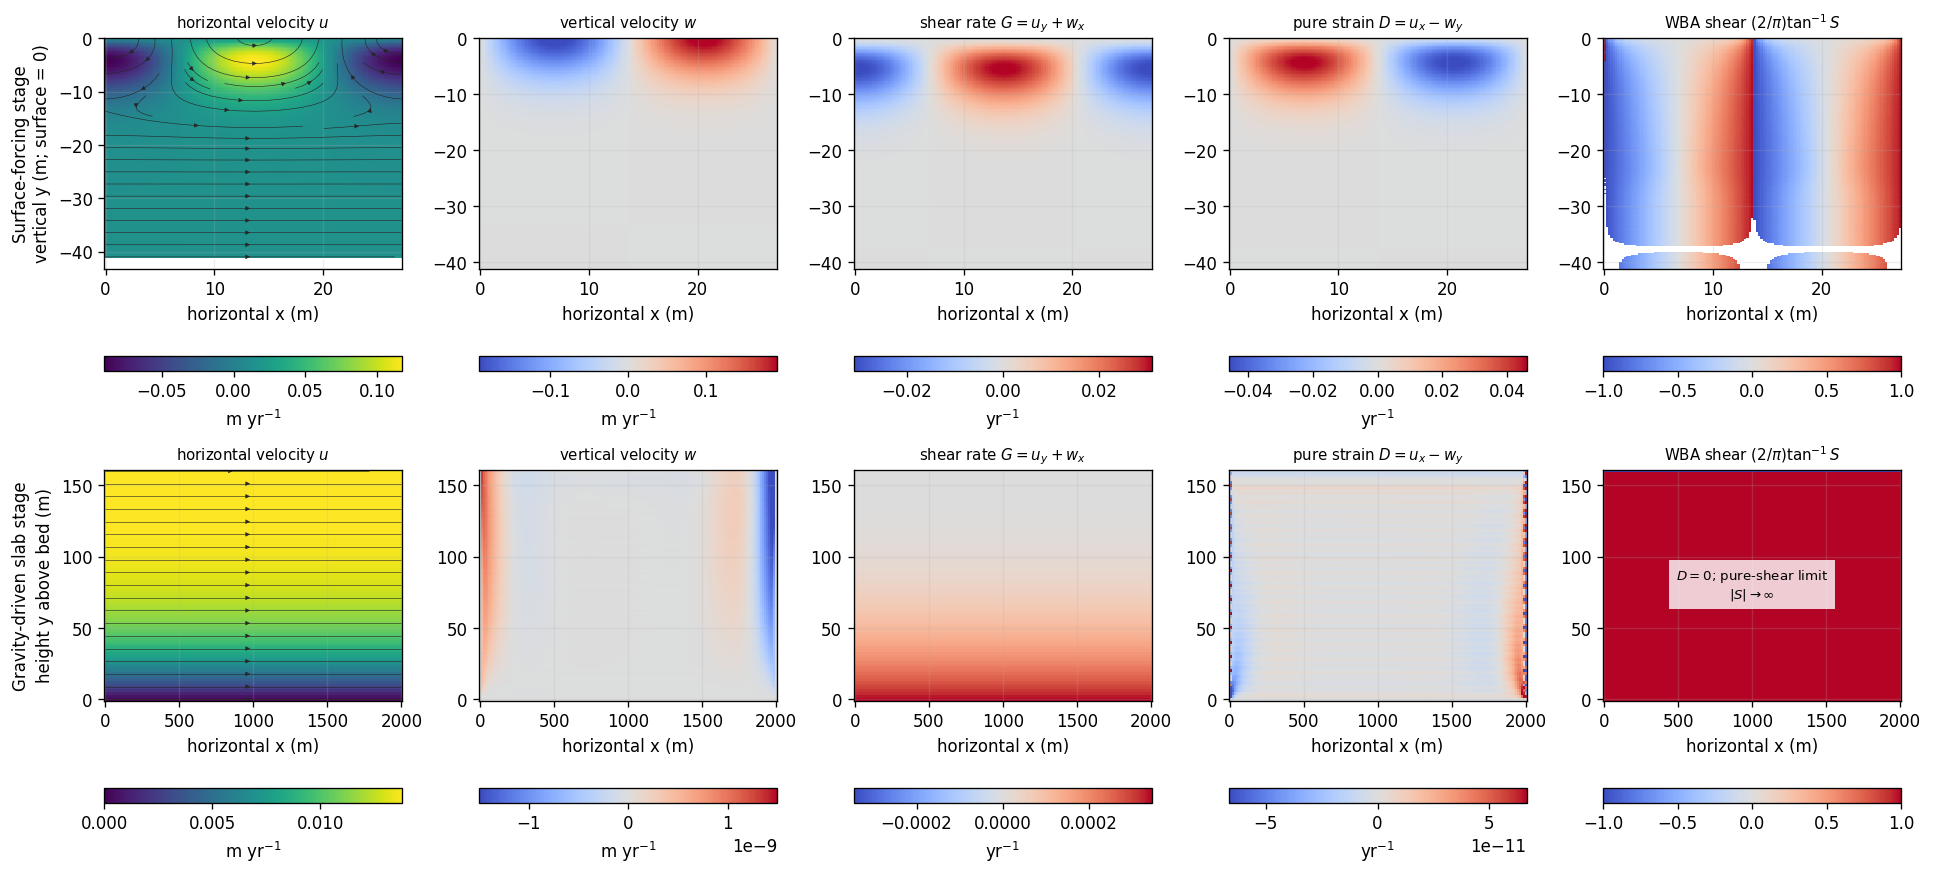

In [6]:
def waddington_fields(x, y, horizontal, vertical):
    du_dy, du_dx = np.gradient(horizontal, y, x, edge_order=2)
    dw_dy, dw_dx = np.gradient(vertical, y, x, edge_order=2)
    shear_rate = du_dy + dw_dx
    pure_strain = du_dx - dw_dy
    tolerance = 1e-6 * max(
        np.max(np.abs(shear_rate)), np.max(np.abs(pure_strain)), 1e-30
    )
    bounded_shear_parameter = np.full_like(shear_rate, np.nan)
    resolved = np.abs(pure_strain) > tolerance
    bounded_shear_parameter[resolved] = (
        2 * np.arctan(shear_rate[resolved] / pure_strain[resolved]) / np.pi
    )
    return shear_rate, pure_strain, bounded_shear_parameter

def signed_limit(field):
    return max(float(np.quantile(np.abs(field), 0.995)), 1e-16)

wavelength = best_case["wavelength"]
surface_rows = surface_depth_grid <= min(1.5 * wavelength, H)
surface_x = surface_phase_grid * wavelength
surface_y = -surface_depth_grid[surface_rows][::-1]
surface_grid = surface_fields[wavelength]["fine_grid"][surface_rows]
surface_u = (
    SURFACE_SPEED * (1 - best_case["speed_ratio"])
    + best_case["b"] * surface_grid[:, :, 0]
)[::-1]
surface_w = (-best_case["b"] * surface_grid[:, :, 1])[::-1]
surface_G, surface_D, surface_S_angle = waddington_fields(
    surface_x, surface_y, surface_u, surface_w
)

slab_x = np.linspace(0.0, L, 161)
slab_y = np.linspace(0.0, H, 81)
slab_X, slab_Y = np.meshgrid(slab_x, slab_y)
slab_points = np.column_stack((slab_X.ravel(), slab_Y.ravel()))
slab_velocity = np.asarray(
    fine_slab["velocity"].at(slab_points, tolerance=1e-9)
).reshape(len(slab_y), len(slab_x), 2)
slab_u, slab_w = slab_velocity[:, :, 0], slab_velocity[:, :, 1]
slab_G, slab_D, _ = waddington_fields(slab_x, slab_y, slab_u, slab_w)
slab_G_tolerance = 1e-6 * max(np.max(np.abs(slab_G)), 1e-30)
slab_S_angle = np.where(np.abs(slab_G) > slab_G_tolerance, np.sign(slab_G), 0.0)

rows = [
    (surface_x, surface_y, surface_u, surface_w, surface_G, surface_D,
     surface_S_angle, "Surface-forcing stage"),
    (slab_x, slab_y, slab_u, slab_w, slab_G, slab_D,
     slab_S_angle, "Gravity-driven slab stage"),
]
fig, axes = plt.subplots(2, 5, figsize=(16.0, 7.2), constrained_layout=True)
column_titles = [
    r"horizontal velocity $u$", r"vertical velocity $w$",
    r"shear rate $G=u_y+w_x$", r"pure strain $D=u_x-w_y$",
    r"WBA shear $(2/\pi)\tan^{-1}S$",
]
for row_index, row in enumerate(rows):
    x_axis, y_axis, u_field, w_field, G_field, D_field, S_field, row_name = row
    fields = [u_field, w_field, G_field, D_field, S_field]
    for column_index, (axis, field, title) in enumerate(
        zip(axes[row_index], fields, column_titles)
    ):
        if column_index == 0:
            image = axis.pcolormesh(x_axis, y_axis, field, shading="auto", cmap="viridis")
        elif column_index == 4:
            image = axis.pcolormesh(
                x_axis, y_axis, field, shading="auto", cmap="coolwarm", vmin=-1, vmax=1
            )
        else:
            limit = signed_limit(field)
            image = axis.pcolormesh(
                x_axis, y_axis, field, shading="auto", cmap="coolwarm",
                vmin=-limit, vmax=limit,
            )
        if column_index == 0:
            axis.streamplot(x_axis, y_axis, u_field, w_field, density=0.65,
                            linewidth=0.35, color="0.15", arrowsize=0.55)
        if row_index == 1 and column_index == 4:
            axis.text(0.5, 0.5, r"$D=0$; pure-shear limit" + "\n" + r"$|S|\rightarrow\infty$",
                      ha="center", va="center", transform=axis.transAxes, fontsize=8,
                      bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"})
        axis.set_title(title, fontsize=9)
        axis.set_xlabel("horizontal x (m)")
        if column_index == 0:
            axis.set_ylabel("vertical y (m; surface = 0)" if row_index == 0
                            else "height y above bed (m)")
            axis.text(-0.28, 0.5, row_name, rotation=90, va="center", ha="center",
                      transform=axis.transAxes, fontsize=10)
        units = "m yr$^{-1}$" if column_index < 2 else (
            "yr$^{-1}$" if column_index < 4 else ""
        )
        fig.colorbar(image, ax=axis, orientation="horizontal", pad=0.13,
                     fraction=0.07, label=units)
plt.show()

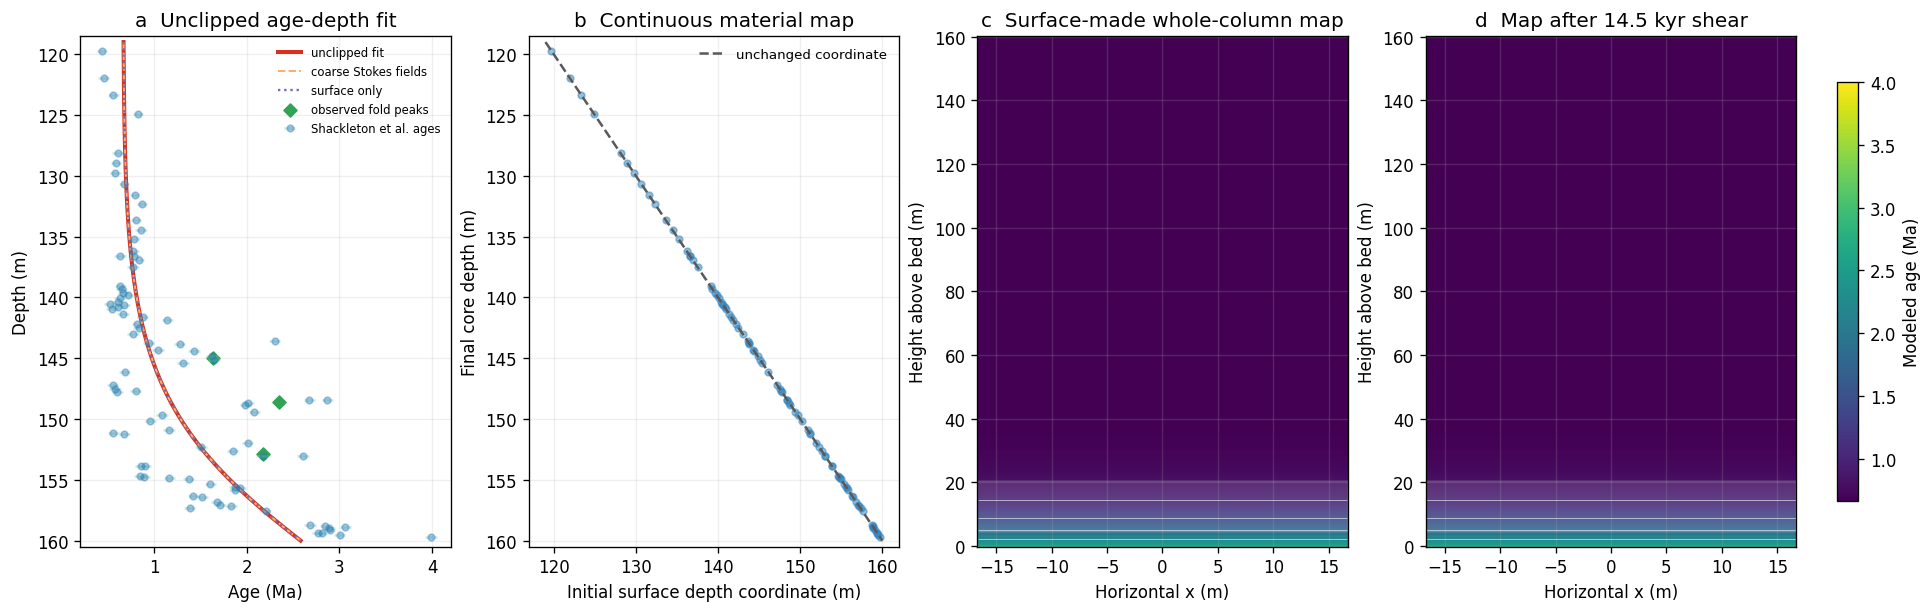

In [7]:
compression, shear_kyr, phase, young_age, age_scale, age_power = best

fig, axes = plt.subplots(1, 4, figsize=(16.0, 5.0), constrained_layout=True)
axes[0].errorbar(age, depth, xerr=relative_error, fmt="o", ms=4, alpha=0.42,
                 color="#2c7fb8", ecolor="#7fcdbb", label="Shackleton et al. ages")
axes[0].plot(fine_curve, fine_curve_depth, color="#d7301f", lw=2.4, label="unclipped fit")
axes[0].plot(coarse_curve, fine_curve_depth, "--", color="#fdae6b", lw=1.2,
             label="coarse Stokes fields")
axes[0].plot(surface_only_curve, fine_curve_depth, ":", color="#756bb1", lw=1.4,
             label="surface only")
axes[0].scatter(observed_peak_ages, observed_peak_depths, marker="D", s=30,
                color="#31a354", label="observed fold peaks")
if len(model_peak_depths):
    axes[0].scatter(model_peak_ages, model_peak_depths, marker="s", s=28,
                    color="#d7301f", label="modeled peaks")
axes[0].set(xlabel="Age (Ma)", ylabel="Depth (m)", title="a  Unclipped age-depth fit",
            ylim=(160.5, 118.5), xlim=(0.2, 4.2))
axes[0].legend(frameon=False, fontsize=7)

axes[1].plot(fitted_initial_depth, depth, "o", ms=4, alpha=0.5, color="#3182bd")
axes[1].plot([119, 160], [119, 160], "--", color="0.35", label="unchanged coordinate")
axes[1].set(xlabel="Initial surface depth coordinate (m)", ylabel="Final core depth (m)",
            title="b  Continuous material map", ylim=(160.5, 118.5))
axes[1].legend(frameon=False, fontsize=8)

x_section = np.linspace(-1.5 * compression * best_case["wavelength"],
                        1.5 * compression * best_case["wavelength"], 501)
z_section = np.linspace(0.0, H, 401)
X, Z = np.meshgrid(x_section, z_section)
depth_section = H - Z

def section_age(shear_time_kyr):
    displacement = shear_time_kyr * 1000 * np.interp(
        Z, fine_slab["heights"], fine_slab["profile"]
    )
    theta = phase + 2 * np.pi * (X - displacement) / (
        compression * best_case["wavelength"]
    )
    initial_depth = sample_surface_map(best_map, theta, depth_section)
    boundary_depth = np.maximum(initial_depth, 0.0)
    return young_age + (4.0 - young_age) * (
        1 - np.exp(-(boundary_depth / age_scale)**age_power)
    )

for axis, field, title in zip(
    axes[2:], [section_age(0.0), section_age(shear_kyr)],
    ["c  Surface-made whole-column map", f"d  Map after {shear_kyr:.1f} kyr shear"],
):
    image = axis.pcolormesh(x_section, z_section, field, shading="auto",
                            cmap="viridis", vmin=young_age, vmax=4.0)
    axis.contour(x_section, z_section, field, levels=np.linspace(1.0, 3.8, 8),
                 colors="white", linewidths=0.45, alpha=0.75)
    axis.axhspan(H - 155.5, H - 139.5, color="white", alpha=0.12)
    axis.set(xlabel="Horizontal x (m)", ylabel="Height above bed (m)", title=title)
fig.colorbar(image, ax=axes[2:], label="Modeled age (Ma)", shrink=0.82)
plt.show()

## Interpretation

This is the direct test of whether the modeled surface episode can seed the observed deep folds without an imposed interior boundary. The diagnostic quantity is the departure of the material coordinate from its initial depth within 139.5--155.5 m. Subsequent simple shear can overturn a sufficiently steep disturbance, but it cannot manufacture a finite disturbance where the surface response has already decayed.

The calculation retains the earlier age law and uniform horizontal-shortening parameter for comparison. These quantities can change the phase and age scale of an existing structure, but they do not insert an old--young contact. Any failure to recover three folds therefore constrains this particular continuous surface-forcing history; it does not rule out a dynamically transported seed or another transient mechanism.